# Computer Vision Workshop: Homework Assignment

This homework is designed to reinforce the concepts learned during the workshop. You will practice image manipulation, edge detection, and advanced facial analysis using DeepFace.

## Instructions
1. Complete all the tasks below.
2. Write your code in the provided cells.
3. Answer the theoretical questions in the markdown cells.

---

## Part 1: Basic Image Processing

### Task 1: Image Transformation
Load an image of your choice (or use `face1.jpg`). Perform the following operations:
1. Convert the image to grayscale.
2. Resize it to 50% of its original size.
3. Rotate it by 90 degrees clockwise.
4. Display the final result.

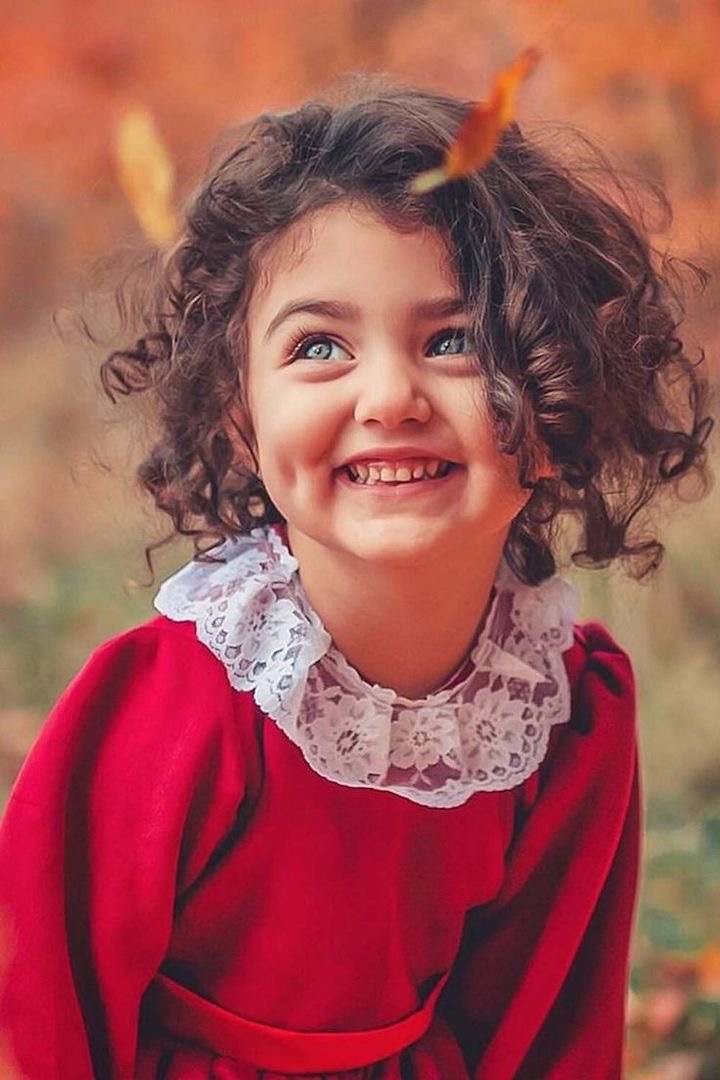

In [18]:
# Your code for Task 1 here
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/sample_data/img1.jpg')
cv2_imshow(img)

In [19]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [20]:
resized_gray = cv2.resize(gray, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

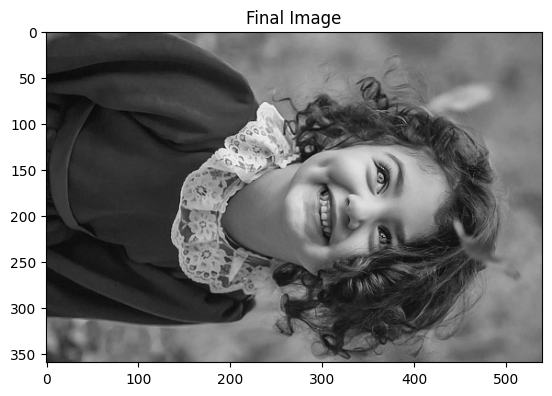

In [21]:
rotated_gray = cv2.rotate(resized_gray, cv2.ROTATE_90_CLOCKWISE)
plt.imshow(rotated_gray, cmap="gray")
plt.title("Final Image")
plt.show()

### Task 2: Edge Detection Comparison
Apply Canny edge detection to an image twice: once with a low threshold (e.g., 50, 100) and once with a high threshold (e.g., 200, 250).

**Question**: What is the difference between the two results? Why does this happen?

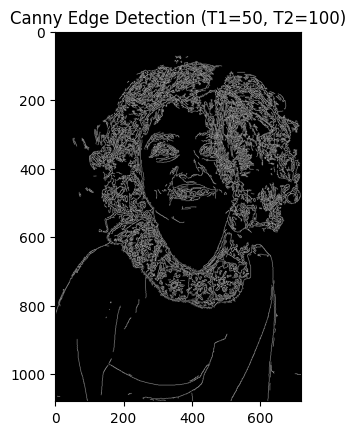

In [22]:
# Your code for Task 2 here
edges1 = cv2.Canny(gray, threshold1=50, threshold2=100)
plt.imshow(edges1, cmap="gray")
plt.title("Canny Edge Detection (T1=50, T2=100)")
plt.show()

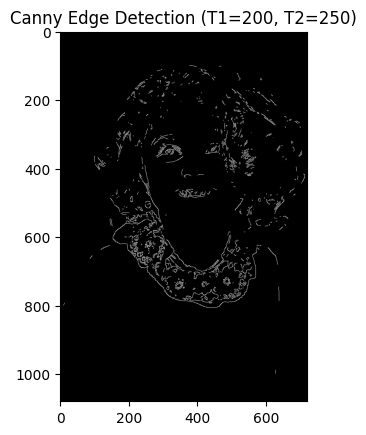

In [23]:
edges2 = cv2.Canny(gray, threshold1=200, threshold2=250)
plt.imshow(edges2, cmap="gray")
plt.title("Canny Edge Detection (T1=200, T2=250)")
plt.show()

**Your Answer for Task 2:**
> High thresholds detect only strong edges (high gradient values), resulting in fewer details. Low thresholds detect both strong and weak edges, resulting in more details.

## Part 2: DeepFace Analysis

### Task 3: Emotion Analysis
Use `DeepFace.analyze` on an image with a clear facial expression.
1. Print the dominant emotion.
2. Print the confidence score for that emotion.

**Question**: Does the AI's prediction match your human interpretation of the expression?

In [24]:
!pip install deepface

In [25]:
# Your code for Task 3 here
from deepface import DeepFace

try:

    obj = DeepFace.analyze(img_path=img,
                            actions = ['emotion'],
                            enforce_detection = True)
    if isinstance(obj, list):
        obj = obj[0]

    print(f"Dominant Emotion: {obj['dominant_emotion']}")
    print("Confidence Score:", obj["emotion"][obj["dominant_emotion"]])

except Exception as e:
    print(f"Error during analysis: {e}")

Dominant Emotion: happy
Confidence Score: 99.281166


**Your Answer for Task 3:**
> Yes. The AI's prediction matches my human interpretation. The detected emotion is "happy" with a confidence score of 99.68%, which is consistent with the facial expression.

### Task 4: Face Verification Challenge
Find two different photos of the same celebrity (e.g., one from 10 years ago and one from today). Use `DeepFace.verify` to see if the system recognizes them as the same person.

**Question**: What was the `distance` score? Did the system succeed or fail? Why might age affect facial recognition?

In [26]:
# Your code for Task 4 here

result = DeepFace.verify(
    img1_path ="/content/sample_data/img2.jpg",
    img2_path = "/content/sample_data/img3.jpg"
)

print("Same person:", result["verified"])
print("Distance score:", result["distance"])

Same person: True
Distance score: 0.340016


**Your Answer for Task 4:**
> The distance score was 0.340016. The system succeeded because it recognized the two images as the same person (Same person: True). Age can affect facial recognition because facial features may change over time, such as changes in skin, hair, and facial structure, which can make recognition more difficult

## Part 3: Critical Thinking

### Question 5: Ethics in Computer Vision
List two potential ethical concerns regarding the use of facial recognition technology in public spaces.

**Your Answer:**

1. Misuse of personal data: Facial recognition data could be misused for tracking people without their knowledge.

2. False identification: The system may incorrectly identify a person, which can lead to unfair consequences.

### Question 6: Real-world Application
Describe a problem in your daily life or industry that could be solved using Computer Vision. What kind of data would you need to collect?

**Your Answer:**
> Problem: Detecting diseases from medical images, such as identifying tumors in MRI scans.
Data needed: A dataset of medical images (MRI/CT/X-ray) labeled by doctors, showing normal and abnormal cases, to train the computer vision model.